# YZ50 — Week 2: Backpropagation

- Backpropagation is a method used in artificial neural networks to calculate the gradients of the loss function by propagating them backward—using the chain rule—from the network's output back to the input.

- A gradient is a vector containing the partial derivatives of a multivariable function with respect to each variable; it indicates the direction and rate at which the function increases.

## Gradient and Its Role in Gradient Descent

- A **gradient** indicates the direction in which a function increases most rapidly and how strongly it changes in that direction.

In neural networks, the gradient of the loss function with respect to the model parameters shows how each weight and bias affects the loss.

Gradient descent uses the gradient to update the model parameters in the opposite direction, with the goal of reducing the loss.

The parameter update rule is:

θ_new = θ_old - η ∇L(θ)

Where:

- **θ** represents the model parameters (weights and biases).
- **∇L(θ)** is the gradient of the loss function with respect to the parameters.
- **η** is the learning rate.

In short, **the gradient tells gradient descent in which direction and by how much the parameters should be changed to reduce the loss.**

# Building a Micrograd (Autograd Engine)

# 1. Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın

- Value class

In [217]:
import math
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # bu node'un gradyanı (derivative of the function with respect to this node).
        self._backward = lambda: None # bu node'un gradyanını hesaplamak için kullanılacak fonksiyon.
        self._prev = set(_children) # bu node'u oluştururken kullanılan önceki Value objelerini saklar.
        self._op = _op # hangi işlemle bu node'un oluşturulduğunu saklar.
        self.label = label

    def __repr__(self):
        return f"Data({self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, _children=(self,), _op='tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
# a + b   = a.__add__(b)
# a * b   = a.__mul__(b)
e = a * b; e.label = 'e'
# d = a*b + c # = (a.__mul__(b)).__add__(c) # '+'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Data(-8.0)

In [218]:
d._prev

{Data(-6.0), Data(10.0)}

In [219]:
d._op

'+'

##  Graph Virtualization

In [220]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

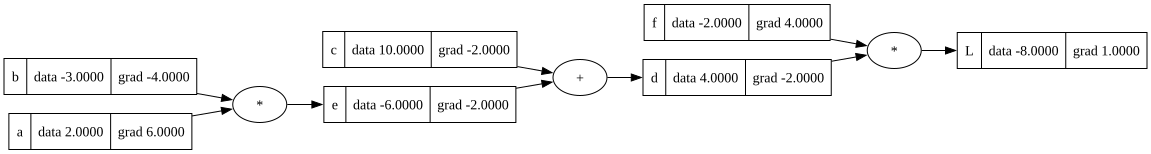

In [237]:
draw_dot(L)

In [222]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
b.grad = -4.0
a.grad = 6.0

- We are able to build mathematical expressions using addition (+) and multiplication (*). So far, these expressions are scalar-valued along the way, and we can perform a forward pass to build a **mathematical expression**. We have multiple inputs here, **(a, b, c, and f)**, going into a mathematical expression that produces a single output, **L**. The output of L is -8.

- What we want to do next is **backpropagation**. In backpropagation, we start from the end and work backward, calculating the gradient with respect to all of the intermediate values. Specifically, we compute the **derivative of the function L with respect to each node**.

- In a neural network setting, we would be taking the derivative of the **Loss Function L** with respect to a **weight of the neural network**. The inputs, such as **a, b, c, and f**, are not weights because they are input values. Since the inputs are fixed, we generally do not need to compute the derivative of the loss with respect to the inputs when updating the network's parameters.

## Mathematical derivative formulas & chain rule

L = d * f
dL/dd = ?

(f(x+h)-f(x))/h

(((d+h)*f)-(d*f))/h

((df+hf)-df)/h

(hf)/h

f

------------------------------------------------

- Chain rule

dL/dc = ?  == (dL/dd) * (dd/dc) = dL/dc

we know dL/dd = f
so find dd/dc

dd/dc = ?

d = e + c

(f(x+h)-f(x))/h

(((c+h)+e)-(c+e))/h

(c+h+e-c-e)/h

h/h

1.0

### So 
dL/dd * dd/dc = dL/dc

f * 1 = f

- also dL/de = f * 1 = f = -2

------------------------------------------------

dL/da = ? ; dL/db = ? 

e = a * b

de/da = b

de/db = a

we know dL/de = f = -2 

dL/de * de/da = dL/da

-2 * b = -2b = 6 

dL/de * de/db = dL/db

-2 * a = -2a = -4

# 2. Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur

- {f(x+h)-f(x)} / h

In [223]:
def lol():

    h = 0.001

    '''Derivative of the function with respect to L.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data + h

    dl_dL = (L2 - L1) / h

    print(f'dL/dL = {dl_dL:.4f}')



    '''Derivative of the function with respect to d.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h # increase d
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_dd = (L2 - L1) / h

    print(f'dL/dd = {dl_dd:.4f}')   



    '''Derivative of the function with respect to f.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    f.data += h # increase f
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_df = (L2 - L1) / h

    print(f'dL/df = {dl_df:.4f}') 


    '''Derivative of the function with respect to c.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    c.data += h # increase c
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_dc = (L2 - L1) / h

    print(f'dL/dc = {dl_dc:.4f}') 

    '''Derivative of the function with respect to e.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e.data += h # increase e
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_de = (L2 - L1) / h

    print(f'dL/de = {dl_de:.4f}') 

    '''Derivative of the function with respect to b.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data += h # increase b
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_db = (L2 - L1) / h

    print(f'dL/db = {dl_db:.4f}')

    '''Derivative of the function with respect to a.'''
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd' 
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    a.data += h # increase a
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    dl_da = (L2 - L1) / h

    print(f'dL/da = {dl_da:.4f}') 

lol()

dL/dL = 1.0000
dL/dd = -2.0000
dL/df = 4.0000
dL/dc = -2.0000
dL/de = -2.0000
dL/db = -4.0000
dL/da = 6.0000


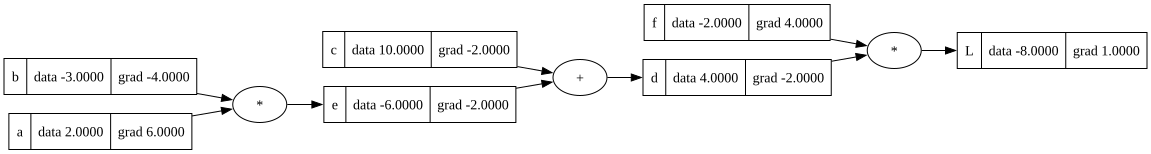

In [236]:
draw_dot(L)

# Geri Yayılım (Backpropagation) Gradyan Akış Kuralları Çıkarımları

## 1. Toplama Kapısı (+) : "Dağıtıcı" (Distributor)
* **Kural:** Toplama işlemi, kendisine gelen gradyanı değiştirmeden tüm girişlerine **aynen dağıtır** (kopyalar).
* **Matematiksel Karşılığı:** $f(x,y) = x + y$ için türevler $1$ olduğu için gelen gradyan $1$ ile çarpılır.

## 2. Çarpma Kapısı (*) : "Çaprazlayıcı" (Switcher)
* **Kural:** Çarpma işlemi, kendisine gelen gradyanı diğer girişin **değeriyle çarparak** (çaprazlayarak) iletir. Bir dalın gradyanını, diğer dalın *ileriye dönük (forward) değeri* belirler.
* **Matematiksel Karşılığı:** $f(x,y) = x * y$ işleminde zincir kuralı (chain rule) gereği türevler yer değiştirir. $x$'in gradyanı hesaplanırken gelen gradyan (e den gelen gradyan [-2]) $y$'nin değeriyle [2] çarpılır.

## Tek bi Nöronda Backpropagation

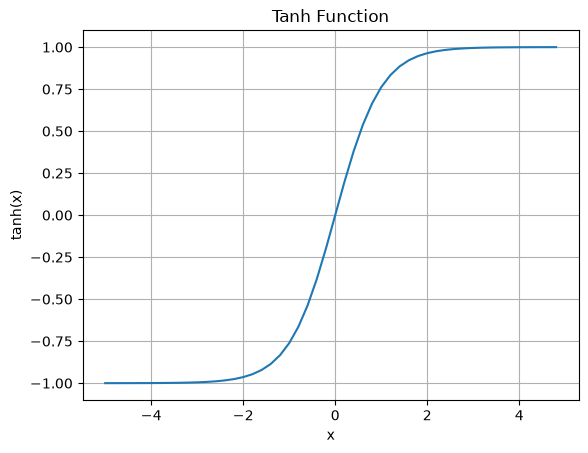

In [225]:
import numpy as np
import matplotlib.pyplot as plt

# tanh function plot
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.title('Tanh Function')
plt.grid(True)
plt.show()

In [226]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137358, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

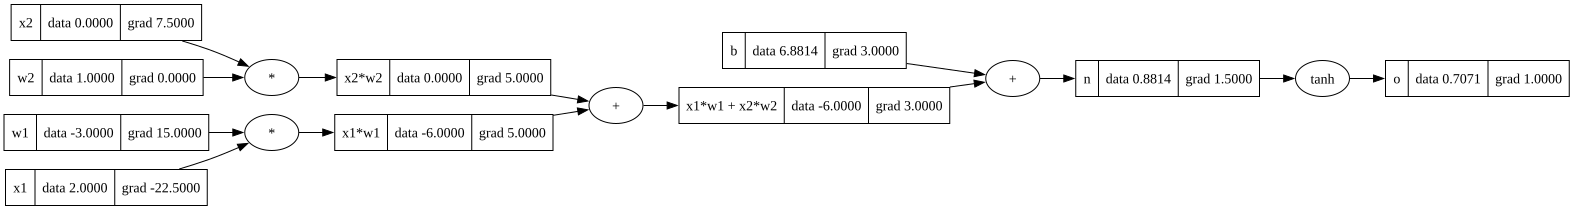

In [235]:
draw_dot(o)

In [228]:
o.backward()

In [229]:
# Manually setting the gradients for backpropagation

o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [230]:
# o = tanh(n)

# do/dn = 1 - tanh(n)**2             ==          1 - o**2

1 - o.data**2

0.5000000049635664

In [231]:
# outomatic backpropagation

o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()
x2._backward()
w2._backward()
x1._backward()
w1._backward()


# 3. backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma



- Topological Sort (Topological Ordering): Yönlü döngüsüz bir grafın (DAG) tüm düğümlerinin, her u→v kenarı için u'nun v'den önce geldiği doğrusal bir sıraya dizilmesidir.

- backpropagation yapabilmemiz için bu topological sortun reversini almamız gerekir

In [232]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

for node in reversed(topo):
    node._backward()

# bu fonksiyonu backward() olarak Value sınıfına ekliyoruz.

### Bir değişken birden fazla işlemde kullanıldığı zaman

**self.grad = out.grad * 1.0** işleminde ardısıra aynı değişkene gelen işlemler yüzünden gradienti üstüne yazma olur.

- Çözüm 

**self.grad += out.grad * 1.0**   gradient böyle senaryolar için += ile toplamak

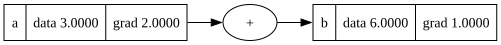

In [233]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

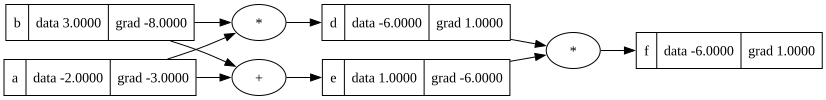

In [234]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b      ; d.label = 'd'
e = a + b      ; e.label = 'e'
f = d * e      ; f.label = 'f'

f.backward()

draw_dot(f)